## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import random

In [2]:
object_name = 'Documents_XVIII_century' # Books / Documents_XVIII_century

In [3]:
if object_name == 'Books':
    real_or_simulated = 'real' #simulated / real / all
    augmentation = False
    augmentation_weights = [0.9, 0.1]
    proportion_of_augmented = 0.25

keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
preprocessing_method = 'logarithm' # normalization / logarithm

columns_to_keep_inks = {
                        'Books': [
                                                 'Al_inks',
                                                 'S_inks',
                                                 'Cr_inks',
                                                 'Mn_inks',
                                                 'Co_inks',
                                                 'Cu_inks',
                                                 'Zn_inks',
                                                 'Pb_inks'],
    
                        'Documents_XVIII_century' : [
                                                 'Al_inks',
                                                 'S_inks',
                                                 'Cr_inks',
                                                 'Mn_inks',
                                                 'Co_inks',
                                                 'Cu_inks',
                                                 'Zn_inks',
                                                 'Pb_inks'
                                                            ],
    
                        'Konstytucja' : [
                                                 'Al',
                                                 'S',
                                                 'Cr',
                                                 'Mn',
                                                 'Co',
                                                 'Cu',
                                                 'Zn',
                                                 'Pb'
                                                            ]
    
                        }

columns_to_keep_inds = { 
                        'Books' : [
                            
                                                 'Al_inds',
                                                 'S_inds',
                                                 'Cr_inds',
                                                 'Mn_inds',
                                                 'Co_inds',
                                                 'Cu_inds',
                                                 'Zn_inds',
                                                 'Pb_inds'],
    
                        'Documents_XVIII_century' : [
                                                 'Al_inds',
                                                 'S_inds',
                                                 'Cr_inds',
                                                 'Mn_inds',
                                                 'Co_inds',
                                                 'Cu_inds',
                                                 'Zn_inds',
                                                 'Pb_inds'
                                                        ],
                        'Konstytucja' : []
    
                        }

In [4]:
data_path = {'Books' : '../data/DANE.xlsx',
             'Documents_XVIII_century' : '../data/Lipiec_2024.xlsx',
             'Konstytucja' : '../data/Lipiec_2024.xlsx'}

results_path = {'Books' : '../results/Books/',
                'Documents_XVIII_century' : '../results/Documents_XVIII_century/',
                'Konstytucja' : '../results/Konstytucja/'}

figures_path = {'Books' : '../results/visualisations/Books/',
                'Documents_XVIII_century' : '../results/visualisations/Documents_XVIII_century/',
                'Konstytucja': '../results/visualisations/Konstytucja/'}

models_path = {'Books' : '../models/Books/',
                'Documents_XVIII_century' : '../models/Documents_XVIII_century/',
                'Konstytucja' : '../models/Konstytucja/'}

1) próbki razem + trzymanie jakiegoś id
2) czyszczenie danych
3) train-test split
4) augmentacja
5) normalizacja
6) ocena jakości

## Loading the data

In [5]:
df = pd.ExcelFile(data_path[object_name])

if object_name == 'Books':
    if real_or_simulated == 'simulated':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    elif real_or_simulated == 'real':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
    elif real_or_simulated == 'all':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

elif object_name == 'Documents_XVIII_century':
    inks_df = df.parse('Arkusz1', header=0, usecols=range(2,29), skiprows=range(3931, 4742))
    inds_df = df.parse('Arkusz1', header=0, usecols=range(32,59), skiprows=range(3931, 4742))
    inds_df.columns = inks_df.columns

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [6]:
inks_df = inks_df.reset_index(drop=False)
inds_df = inds_df.reset_index(drop=False)
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

In [7]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Keeping track of the records from the same sample

In [8]:
inDKs_df['Sample_id'] = np.repeat(range(int(inDKs_df.shape[0]/15)), 15, axis=0)

In [9]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df)

### Removing some data

1. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [10]:
inDKs_df = inDKs_df[columns_to_keep_inks[object_name] + columns_to_keep_inds[object_name] + ['Sample_id']]

2. Let's remove rows with missing values.

In [11]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.007888040712468193

In [12]:
inDKs_df.dropna(inplace=True)

### Train test split, datasets, dataloaders

In [13]:
if keep_sample_together:
    
    indices = list(inDKs_df['Sample_id'].unique())
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    X_y_train = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_train)]
    X_y_val = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_val)]
    X_y_test = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_test)]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

else:
    indices = list(range(int(inDKs_df.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)
    
    partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}
    
    X_y_train = inDKs_df.iloc[partition['train'],:]
    X_y_val = inDKs_df.iloc[partition['val'],:]
    X_y_test = inDKs_df.iloc[partition['test'],:]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

### Data augmentation

In [14]:
if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    inks_df_sim = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df_sim = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    inks_df_sim.reset_index(drop=False, inplace=True)
    inds_df_sim.reset_index(drop=False, inplace=True)
    inDKs_df_sim = inds_df_sim.join(inks_df_sim, how='inner', rsuffix='_inks', lsuffix='_inds')
    ids_sim = range(inDKs_df['Sample_id'].max()+1, inDKs_df['Sample_id'].max() + 1 + int(inDKs_df_sim.shape[0]/15))
    inDKs_df_sim['Sample_id'] = np.repeat(ids_sim, 15, axis=0)
    inDKs_df_sim.dropna(inplace=True)
    inDKs_df_sim = inDKs_df_sim[inks_colnames + inds_colnames + ['Sample_id']]

In [15]:
if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    indices_to_mix_real = random.sample(range(X_y_train.shape[0]), 
                                        int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_to_mix_sim = random.sample(range(inDKs_df_sim.shape[0]), 
                                       int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_not_to_mix_real = list(set(range(X_y_train.shape[0])).difference(set(indices_to_mix_real)))
    indices_not_to_mix_sim = list(set(range(inDKs_df_sim.shape[0])).difference(set(indices_to_mix_sim)))

    real_not_to_mix = X_y_train.iloc[indices_not_to_mix_real,:]
    real_to_mix = X_y_train.iloc[indices_to_mix_real,:]
    sim_to_mix = inDKs_df_sim.iloc[indices_to_mix_sim,:]
    real_not_to_mix.reset_index(inplace=True, drop=True)
    real_to_mix.reset_index(inplace=True, drop=True)
    sim_to_mix.reset_index(inplace=True, drop=True)
    X_y_augmented = \
                real_to_mix.loc[:, real_to_mix.columns != 'Sample_id']*augmentation_weights[0] + \
                sim_to_mix.loc[:, sim_to_mix.columns != 'Sample_id']*augmentation_weights[1]
    X_y_augmented['Sample_id_real'] = real_to_mix['Sample_id']
    X_y_augmented['Sample_id_sim'] = sim_to_mix['Sample_id']

    X_y_train = real_not_to_mix

### Creating features and labels matrices

In [16]:
train_order = X_y_train['Sample_id']
val_order = X_y_val['Sample_id']
test_order = X_y_test['Sample_id']

if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    augmented_real_order = X_y_augmented['Sample_id_real']
    augmented_sim_order = X_y_augmented['Sample_id_sim']

X_train = np.array(X_y_train[columns_to_keep_inds[object_name]].values)
y_train = np.array(X_y_train[columns_to_keep_inks[object_name]].values)
X_val = np.array(X_y_val[columns_to_keep_inds[object_name]].values)
y_val = np.array(X_y_val[columns_to_keep_inks[object_name]].values)
X_test = np.array(X_y_test[columns_to_keep_inds[object_name]].values)
y_test = np.array(X_y_test[columns_to_keep_inks[object_name]].values)

if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    X_augmented = np.array(X_y_augmented[columns_to_keep_inds[object_name]].values)
    y_augmented = np.array(X_y_augmented[columns_to_keep_inks[object_name]].values)

### Normalization / taking logarithm

In [17]:
def adjusted_log_transform(nonnegative_array):
    res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)
    res = np.where(res != 0, res, 2*res.min(axis=0))
    return res

In [18]:
if preprocessing_method == 'normalization':
    
    if object_name == 'Books' and real_or_simulated == 'real' and augmentation:

        X_all = np.concatenate([X_train, X_augmented])
        y_all = np.concatenate([y_train, y_augmented])

        X_all = (X_all - np.min(X_all, axis=0))/np.std(X_all, axis=0)
        y_all = (y_all - np.min(y_all, axis=0))/np.std(y_all, axis=0)

        X_train = X_all[:X_train.shape[0],:]
        X_augmented = X_all[X_train.shape[0]:,:]
        y_train = y_all[:y_train.shape[0],:]
        y_augmented = y_all[y_train.shape[0]:,:]
        
    else:
        
        X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
        y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
        
        X_all = np.concatenate([X_train, X_augmented])
        y_all = np.concatenate([y_train, y_augmented])
        
        X_all = adjusted_log_transform(X_all)
        y_all = adjusted_log_transform(y_all)
        
        X_train = X_all[:X_train.shape[0],:]
        X_augmented = X_all[X_train.shape[0]:,:]
        y_train = y_all[:y_train.shape[0],:]
        y_augmented = y_all[y_train.shape[0]:,:]
        
    else:
        
        X_train = adjusted_log_transform(X_train)
        y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)
    
elif preprocessing_method == 'logarithm_and_normalization':
    
    #logarithm
    if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
        
        X_all = np.concatenate([X_train, X_augmented])
        y_all = np.concatenate([y_train, y_augmented])
        
        X_all = adjusted_log_transform(X_all)
        y_all = adjusted_log_transform(y_all)
        
        X_train = X_all[:X_train.shape[0],:]
        X_augmented = X_all[X_train.shape[0]:,:]
        y_train = y_all[:y_train.shape[0],:]
        y_augmented = y_all[y_train.shape[0]:,:]
        
    else:
        
        X_train = adjusted_log_transform(X_train)
        y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)
    
    #normalization
    if object_name == 'Books' and real_or_simulated == 'real' and augmentation:

        X_all = np.concatenate([X_train, X_augmented])
        y_all = np.concatenate([y_train, y_augmented])

        X_all = (X_all - np.min(X_all, axis=0))/np.std(X_all, axis=0)
        y_all = (y_all - np.min(y_all, axis=0))/np.std(y_all, axis=0)

        X_train = X_all[:X_train.shape[0],:]
        X_augmented = X_all[X_train.shape[0]:,:]
        y_train = y_all[:y_train.shape[0],:]
        y_augmented = y_all[y_train.shape[0]:,:]
        
    else:
        
        X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
        y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)

/tmp/ipykernel_17931/1324458353.py:2: RuntimeWarning: divide by zero encountered in log
  res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)


In [19]:
#plt.hist(X_val[:,2], bins=100)

### Converting to tensors

In [20]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [21]:
if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    
    X_train = torch.Tensor(np.concatenate([X_train, X_augmented])).to(device)
    y_train = torch.Tensor(np.concatenate([y_train, y_augmented])).to(device)
    
else:
    
    X_train = torch.Tensor(X_train).to(device)
    y_train = torch.Tensor(y_train).to(device)
    
X_val = torch.Tensor(X_val).to(device)
y_val = torch.Tensor(y_val).to(device)
X_test = torch.Tensor(X_test).to(device)
y_test = torch.Tensor(y_test).to(device)

### Dataset

In [22]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [23]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [24]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [25]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [ ]:
dropout_prob = 0.02

class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, 32),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(32, 64),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
        nn.Linear(64, 32),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(32, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [28]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): Dropout(p=0.02, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): Dropout(p=0.02, inplace=False)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Dropout(p=0.02, inplace=False)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=32, bias=True)
    (10): Dropout(p=0.02, inplace=False)
    (11): ReLU()
    (12): Linear(in_features=32, out_features=8, bias=True)
  )
)


In [29]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

1/2, 1/4, 1/8, 1/40, 1/40, 1/40, 1/40, 1/40

1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40


In [30]:
#weights = torch.tensor([1/2,1/4,1/8,1/40,1/40,1/40,1/40,1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/3,1/3,1/18,1/18,1/18,1/18,1/18,1/18]).unsqueeze(1).to(device)
weights = torch.tensor([1/8,1/8,1/8,1/8,1/8,1/8,1/8,1/8]).unsqueeze(1).to(device)
#weights = torch.tensor([1/4, 1/20, 1/20, 1/4, 1/20, 1/4, 1/20, 1/20]).unsqueeze(1).to(device)


class CustomLoss(nn.Module):
    def __init__(self, weights=weights):
        super(CustomLoss, self).__init__()
        self.weights = weights
        assert weights.shape[1] == 1

    def forward(self, outputs, targets):
        inner_loss = nn.L1Loss(reduction='none')
        res = inner_loss(outputs, targets)
        res = torch.mm(res, self.weights)
        res = res.mean(axis=0)
#         inner_loss_to_compare = nn.L1Loss(reduction='mean')
#         assert torch.isclose(inner_loss_to_compare(outputs, targets), res)
        return res

In [31]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss*(1-dropout_prob)))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 3.1801145871480307 test 2.6124079996546112
EPOCH 2:
LOSS train 1.7814880510171254 test 1.2876359921747291
EPOCH 3:
LOSS train 1.265001450975736 test 1.1299684093984272
EPOCH 4:
LOSS train 1.1788953493038814 test 1.070979447661302
EPOCH 5:
LOSS train 1.135903591910998 test 1.0320504543208158
EPOCH 6:
LOSS train 1.0912572642167409 test 1.0004943481339856
EPOCH 7:
LOSS train 1.0625241448481877 test 0.9593527617668494
EPOCH 8:
LOSS train 1.0220645144581795 test 0.920121450276329
EPOCH 9:
LOSS train 0.9832091604669889 test 0.887808651903883
EPOCH 10:
LOSS train 0.9449840063850085 test 0.8617055482119322
EPOCH 11:
LOSS train 0.9285170137882233 test 0.8239953051702334
EPOCH 12:
LOSS train 0.9005351314942042 test 0.809176664050191
EPOCH 13:
LOSS train 0.8885288710395495 test 0.7951034434309755
EPOCH 14:
LOSS train 0.8736985797683398 test 0.783599445015001
EPOCH 15:
LOSS train 0.8667047793666521 test 0.7692892497839072
EPOCH 16:
LOSS train 0.8587682271997134 test 0.758788499

LOSS train 0.5965808555483818 test 0.531138356377681
EPOCH 131:
LOSS train 0.5898219446341196 test 0.5273317019408329
EPOCH 132:
LOSS train 0.5942918285727501 test 0.5307258203698274
EPOCH 133:
LOSS train 0.5926122243205706 test 0.5255477759882043
EPOCH 134:
LOSS train 0.5859212304155031 test 0.524755015802307
EPOCH 135:
LOSS train 0.5852958187460899 test 0.5254148336818967
EPOCH 136:
LOSS train 0.5894782145818075 test 0.5246143168801298
EPOCH 137:
LOSS train 0.5874768843253454 test 0.5165616916127693
EPOCH 138:
LOSS train 0.5854094276825587 test 0.5299749111579014
EPOCH 139:
LOSS train 0.5856551801164945 test 0.5283103590059357
EPOCH 140:
LOSS train 0.5820563038190206 test 0.5242231013788244
EPOCH 141:
LOSS train 0.5864192123214403 test 0.5290938281980463
EPOCH 142:
LOSS train 0.5873641048868498 test 0.5562863447700556
EPOCH 143:
LOSS train 0.5875634203354517 test 0.524285207017492
EPOCH 144:
LOSS train 0.5807949230074883 test 0.5247575319978671
EPOCH 145:
LOSS train 0.585978123048941

LOSS train 0.5263861815134684 test 0.47519285787756627
EPOCH 258:
LOSS train 0.5236764525373777 test 0.4743153052356763
EPOCH 259:
LOSS train 0.5186102204024792 test 0.4729648540002795
EPOCH 260:
LOSS train 0.5191702743371328 test 0.47387842050786966
EPOCH 261:
LOSS train 0.5225474449495474 test 0.4816291203934413
EPOCH 262:
LOSS train 0.5155102151135603 test 0.47402006686478854
EPOCH 263:
LOSS train 0.5187976844608784 test 0.47235665792322307
EPOCH 264:
LOSS train 0.5237577694157759 test 0.4795711866080379
EPOCH 265:
LOSS train 0.5184097997844219 test 0.4727939923808743
EPOCH 266:
LOSS train 0.519401869426171 test 0.471956637300742
EPOCH 267:
LOSS train 0.5233035696049532 test 0.4767509652013198
EPOCH 268:
LOSS train 0.5201237325867017 test 0.4737194452062249
EPOCH 269:
LOSS train 0.5179225616157055 test 0.47497534329501484
EPOCH 270:
LOSS train 0.5154823785026869 test 0.4709922018198248
EPOCH 271:
LOSS train 0.5132088040312132 test 0.4703083427380293
EPOCH 272:
LOSS train 0.515709734

LOSS train 0.4664679641524951 test 0.43735768594535496
EPOCH 383:
LOSS train 0.47074296946326893 test 0.4497519920579134
EPOCH 384:
LOSS train 0.4779096667965253 test 0.4395422233203665
EPOCH 385:
LOSS train 0.4756280469397704 test 0.43583099770354916
EPOCH 386:
LOSS train 0.4738403980930646 test 0.4354866820145876
EPOCH 387:
LOSS train 0.47246064866582554 test 0.43457498850453735
EPOCH 388:
LOSS train 0.4695466222862403 test 0.4340003121848672
EPOCH 389:
LOSS train 0.4752545890708764 test 0.44542193377533784
EPOCH 390:
LOSS train 0.47398290038108826 test 0.4426652121716776
EPOCH 391:
LOSS train 0.468110849459966 test 0.43897078720766763
EPOCH 392:
LOSS train 0.4619063660502434 test 0.43973489599006294
EPOCH 393:
LOSS train 0.4708407086630662 test 0.4422437791786133
EPOCH 394:
LOSS train 0.46999509632587433 test 0.4330252126875596
EPOCH 395:
LOSS train 0.47018369287252426 test 0.43548568813999494
EPOCH 396:
LOSS train 0.4683471731841564 test 0.44241590213469967
EPOCH 397:
LOSS train 0.

LOSS train 0.44195546582341194 test 0.41681698876199047
EPOCH 508:
LOSS train 0.44190770015120506 test 0.4205434077175764
EPOCH 509:
LOSS train 0.43736236294110614 test 0.4183982068106341
EPOCH 510:
LOSS train 0.434657484292984 test 0.4158402712650788
EPOCH 511:
LOSS train 0.447135570148627 test 0.415180932714771
EPOCH 512:
LOSS train 0.43559350694219273 test 0.4147781956558808
EPOCH 513:
LOSS train 0.43576836834351224 test 0.41757169685856654
EPOCH 514:
LOSS train 0.44062068810065586 test 0.41818861718256123
EPOCH 515:
LOSS train 0.4319570412238439 test 0.4143544092594813
EPOCH 516:
LOSS train 0.43336184819539386 test 0.4143882104315055
EPOCH 517:
LOSS train 0.4333638983468215 test 0.4130637789035264
EPOCH 518:
LOSS train 0.4362316355109215 test 0.41462853857913073
EPOCH 519:
LOSS train 0.4377925172448158 test 0.4164753347851145
EPOCH 520:
LOSS train 0.43262933070460957 test 0.4125559328759137
EPOCH 521:
LOSS train 0.43721073617537815 test 0.41438742820880353
EPOCH 522:
LOSS train 0.4

...

LOSS train 0.281554385398825 test 0.33524694888752243
EPOCH 4452:
LOSS train 0.2850883516172568 test 0.3387583399970944
EPOCH 4453:
LOSS train 0.2769936801244815 test 0.3358202307572923
EPOCH 4454:
LOSS train 0.27909308796127635 test 0.3318151597310908
EPOCH 4455:
LOSS train 0.27423774637281895 test 0.33775599598693545
EPOCH 4456:
LOSS train 0.2750527299940586 test 0.3334076277423555
EPOCH 4457:
LOSS train 0.28246981961031753 test 0.3317973168120743
EPOCH 4458:
LOSS train 0.28534319748481113 test 0.329841334015322
EPOCH 4459:
LOSS train 0.28219045015672845 test 0.33115641364225973
EPOCH 4460:
LOSS train 0.2860534315307935 test 0.33199327469168183
EPOCH 4461:
LOSS train 0.2813653399546941 test 0.33672782597155904
EPOCH 4462:
LOSS train 0.2799613190193971 test 0.3326156565565138
EPOCH 4463:
LOSS train 0.2791469519337018 test 0.33239522037750635
EPOCH 4464:
LOSS train 0.28980437728265923 test 0.3367883646467175
EPOCH 4465:
LOSS train 0.28707774356007576 test 0.33324068752418345
EPOCH 4466

LOSS train 0.2889643193533023 test 0.3277981121987104
EPOCH 4575:
LOSS train 0.2823938212047021 test 0.3302584991711072
EPOCH 4576:
LOSS train 0.2793059380104144 test 0.329611709106618
EPOCH 4577:
LOSS train 0.28288322252531845 test 0.33050699108600234
EPOCH 4578:
LOSS train 0.2839574894557397 test 0.3304014189169766
EPOCH 4579:
LOSS train 0.27088146284222603 test 0.3308047484981899
EPOCH 4580:
LOSS train 0.28231444396078587 test 0.3310692221762087
EPOCH 4581:
LOSS train 0.2887680468459924 test 0.3338752963249691
EPOCH 4582:
LOSS train 0.2878706846386194 test 0.3278645063577554
EPOCH 4583:
LOSS train 0.2815953151633342 test 0.3304411024763607
EPOCH 4584:
LOSS train 0.2904880332450072 test 0.3311169543627363
EPOCH 4585:
LOSS train 0.2797796117762725 test 0.32994826826395895
EPOCH 4586:
LOSS train 0.2825554454078277 test 0.3313221488581636
EPOCH 4587:
LOSS train 0.27587249005834263 test 0.3308041280520459
EPOCH 4588:
LOSS train 0.2764301598072052 test 0.33165556588826267
EPOCH 4589:
LOSS

LOSS train 0.27672633652885753 test 0.3340411682440302
EPOCH 4699:
LOSS train 0.28494076430797577 test 0.3316692983047702
EPOCH 4700:
LOSS train 0.28238044244547683 test 0.3312071280563489
EPOCH 4701:
LOSS train 0.2790168573458989 test 0.32930581539697373
EPOCH 4702:
LOSS train 0.2820304352790117 test 0.335137661109177
EPOCH 4703:
LOSS train 0.2817103086660306 test 0.33099432224159436
EPOCH 4704:
LOSS train 0.28505928193529445 test 0.331357406557466
EPOCH 4705:
LOSS train 0.2799489926546812 test 0.3321770323001039
EPOCH 4706:
LOSS train 0.2845990030715863 test 0.3369504138621
EPOCH 4707:
LOSS train 0.2767813454071681 test 0.3341603498121676
EPOCH 4708:
LOSS train 0.285703315710028 test 0.3303402004797871
EPOCH 4709:
LOSS train 0.2769172204037507 test 0.3307393563484343
EPOCH 4710:
LOSS train 0.2827574070543051 test 0.3347775668466511
EPOCH 4711:
LOSS train 0.27597716078162193 test 0.33562585507619835
EPOCH 4712:
LOSS train 0.27936122256020707 test 0.332562121045513
EPOCH 4713:
LOSS tra

LOSS train 0.281195817515254 test 0.3291133285662493
EPOCH 4822:
LOSS train 0.27961401641368866 test 0.33331937826023655
EPOCH 4823:
LOSS train 0.2875377895931403 test 0.3319959039117854
EPOCH 4824:
LOSS train 0.2866033961375554 test 0.3336366566043251
EPOCH 4825:
LOSS train 0.2762296963483095 test 0.33188738799353057
EPOCH 4826:
LOSS train 0.280237744251887 test 0.33053352631695376
EPOCH 4827:
LOSS train 0.2815307881683111 test 0.3280240383572303
EPOCH 4828:
LOSS train 0.27944328635931015 test 0.3299968651715571
EPOCH 4829:
LOSS train 0.27393848324815434 test 0.32936097593767905
EPOCH 4830:
LOSS train 0.2780641224235296 test 0.3344116192907095
EPOCH 4831:
LOSS train 0.2814986873418093 test 0.33149674118615874
EPOCH 4832:
LOSS train 0.2831732388585806 test 0.3311921336993766
EPOCH 4833:
LOSS train 0.27457390042642754 test 0.33010622387809246
EPOCH 4834:
LOSS train 0.2813944003234307 test 0.33160132146980137
EPOCH 4835:
LOSS train 0.28488527548809844 test 0.3293108080507089
EPOCH 4836:


LOSS train 0.2821177902321021 test 0.3315829138586728
EPOCH 4945:
LOSS train 0.2803284004330635 test 0.33191922432738236
EPOCH 4946:
LOSS train 0.2800407738735278 test 0.33113359863559405
EPOCH 4947:
LOSS train 0.280749316016833 test 0.32960701414627525
EPOCH 4948:
LOSS train 0.2850207568456729 test 0.33265943051568975
EPOCH 4949:
LOSS train 0.27211725277205306 test 0.3365033873298611
EPOCH 4950:
LOSS train 0.2798727713525295 test 0.32828571060108835
EPOCH 4951:
LOSS train 0.27995268255472183 test 0.3301780403133195
EPOCH 4952:
LOSS train 0.2774440950403611 test 0.3325850928112482
EPOCH 4953:
LOSS train 0.284200357273221 test 0.3336269605887624
EPOCH 4954:
LOSS train 0.2867194935679436 test 0.32800362020759627
EPOCH 4955:
LOSS train 0.28478184280296165 test 0.3288776220824474
EPOCH 4956:
LOSS train 0.2872258039812247 test 0.33191965658494677
EPOCH 4957:
LOSS train 0.27189716572562855 test 0.3325119511599724
EPOCH 4958:
LOSS train 0.2816951076189677 test 0.3280674499900868
EPOCH 4959:
L

In [30]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss*(1-dropout_prob)))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 3.0518714984258017 test 2.4490630393777137
EPOCH 2:
LOSS train 1.8519701659679413 test 1.2717567730721755
EPOCH 3:
LOSS train 1.2696581135193508 test 1.113655937359119
EPOCH 4:
LOSS train 1.1341789389650028 test 1.0186079768645457
EPOCH 5:
LOSS train 1.0709613660971324 test 0.9614328190722526
EPOCH 6:
LOSS train 1.0208884353439014 test 0.9129391899395448
EPOCH 7:
LOSS train 0.9770836432774862 test 0.8753582224498193
EPOCH 8:
LOSS train 0.9490053976575533 test 0.8446447004928038
EPOCH 9:
LOSS train 0.9124778658151627 test 0.8161474302288814
EPOCH 10:
LOSS train 0.8966038102904955 test 0.7953732331567086
EPOCH 11:
LOSS train 0.8784806231657664 test 0.7802275135922127
EPOCH 12:
LOSS train 0.8606192121903101 test 0.7624730640363234
EPOCH 13:
LOSS train 0.8441591709852219 test 0.7513691036823469
EPOCH 14:
LOSS train 0.8350242351492246 test 0.7396248061846082
EPOCH 15:
LOSS train 0.8296948497494062 test 0.741263038876347
EPOCH 16:
LOSS train 0.8187696983416876 test 0.7312

LOSS train 0.6186628490686417 test 0.5575889237364514
EPOCH 130:
LOSS train 0.6146614998579025 test 0.5661316323547791
EPOCH 131:
LOSS train 0.6147391175230345 test 0.5519852412150074
EPOCH 132:
LOSS train 0.615805484354496 test 0.5585825245296343
EPOCH 133:
LOSS train 0.6172405704855919 test 0.5596732571776479
EPOCH 134:
LOSS train 0.6125732436776161 test 0.5556507918670391
EPOCH 135:
LOSS train 0.6151259069641432 test 0.5601961926558079
EPOCH 136:
LOSS train 0.6150980989138285 test 0.5570354524368467
EPOCH 137:
LOSS train 0.6121153955658277 test 0.5622243394190685
EPOCH 138:
LOSS train 0.6130906591812769 test 0.5529158848053178
EPOCH 139:
LOSS train 0.6113240346312523 test 0.5548559319652044
EPOCH 140:
LOSS train 0.6091098338365555 test 0.5539224185914947
EPOCH 141:
LOSS train 0.6091435725490252 test 0.5544887922409062
EPOCH 142:
LOSS train 0.6144929553071657 test 0.5513188355696889
EPOCH 143:
LOSS train 0.6094612578550974 test 0.5561187309540617
EPOCH 144:
LOSS train 0.6149679596225

LOSS train 0.5633038381735483 test 0.517826750137676
EPOCH 257:
LOSS train 0.55790022884806 test 0.5186473342533676
EPOCH 258:
LOSS train 0.5595662867029508 test 0.5166776298988515
EPOCH 259:
LOSS train 0.5604348157842954 test 0.5160610874965786
EPOCH 260:
LOSS train 0.5496779518822829 test 0.5210537212928518
EPOCH 261:
LOSS train 0.5501383543014526 test 0.5167496734737204
EPOCH 262:
LOSS train 0.557518425087134 test 0.5167924919523872
EPOCH 263:
LOSS train 0.55365967998902 test 0.5181292920246339
EPOCH 264:
LOSS train 0.5578587055206299 test 0.5230150629638288
EPOCH 265:
LOSS train 0.5571962843338648 test 0.5208144536887606
EPOCH 266:
LOSS train 0.5554044234255949 test 0.5134823293038285
EPOCH 267:
LOSS train 0.5502987975875536 test 0.5133695511087202
EPOCH 268:
LOSS train 0.5519029125571251 test 0.5123648125162491
EPOCH 269:
LOSS train 0.5586613938212395 test 0.509166646771515
EPOCH 270:
LOSS train 0.551551683495442 test 0.5099363634490813
EPOCH 271:
LOSS train 0.5577437318861485 tes

LOSS train 0.5210083437462648 test 0.4840762998853356
EPOCH 383:
LOSS train 0.5162862253685793 test 0.49070067948160256
EPOCH 384:
LOSS train 0.5263845237592856 test 0.49218588824016163
EPOCH 385:
LOSS train 0.5228214164574941 test 0.49111036466673397
EPOCH 386:
LOSS train 0.5236191290120283 test 0.48676581697280585
EPOCH 387:
LOSS train 0.521372601389885 test 0.48981966472589056
EPOCH 388:
LOSS train 0.514348603785038 test 0.49021856606465114
EPOCH 389:
LOSS train 0.5177713160713514 test 0.4822159437858141
EPOCH 390:
LOSS train 0.5102748200297356 test 0.48148150360909026
EPOCH 391:
LOSS train 0.5113699821134409 test 0.487981417468343
EPOCH 392:
LOSS train 0.5151095278561115 test 0.4839288117209306
EPOCH 393:
LOSS train 0.5158814080059528 test 0.4809109415035599
EPOCH 394:
LOSS train 0.515278539309899 test 0.48821452545011657
EPOCH 395:
LOSS train 0.5128870829939842 test 0.48335832431606757
EPOCH 396:
LOSS train 0.5126022957265377 test 0.4820425860782464
EPOCH 397:
LOSS train 0.5142089

LOSS train 0.49224884311358136 test 0.4641654377463154
EPOCH 509:
LOSS train 0.48861900096138317 test 0.4587406574350137
EPOCH 510:
LOSS train 0.4820302538573742 test 0.4618864708926815
EPOCH 511:
LOSS train 0.4916446842253208 test 0.45983560211478897
EPOCH 512:
LOSS train 0.48314673950274784 test 0.4644006957312425
EPOCH 513:
LOSS train 0.49051711211601895 test 0.45977744958301386
EPOCH 514:
LOSS train 0.49253113319476444 test 0.45939070761261075
EPOCH 515:
LOSS train 0.49476952850818634 test 0.473847873710669
EPOCH 516:
LOSS train 0.48695559923847515 test 0.4597507507875562
EPOCH 517:
LOSS train 0.48580849170684814 test 0.4616280886609203
EPOCH 518:
LOSS train 0.4899704655011495 test 0.46202128137094084
EPOCH 519:
LOSS train 0.49117733910679817 test 0.45870367446388954
EPOCH 520:
LOSS train 0.4870692553619544 test 0.4644503578020212
EPOCH 521:
LOSS train 0.48656153306365013 test 0.4607722802318824
EPOCH 522:
LOSS train 0.49122851838668186 test 0.4589535593730517
EPOCH 523:
LOSS train

...

LOSS train 0.3556500126918157 test 0.385274197664876
EPOCH 4453:
LOSS train 0.35095611090461415 test 0.3850033984785088
EPOCH 4454:
LOSS train 0.339064285159111 test 0.3846398531949291
EPOCH 4455:
LOSS train 0.34971657395362854 test 0.3831615207170446
EPOCH 4456:
LOSS train 0.3499598676959674 test 0.38464061695776686
EPOCH 4457:
LOSS train 0.34261692066987354 test 0.3823918138591525
EPOCH 4458:
LOSS train 0.350523866713047 test 0.3836900752299489
EPOCH 4459:
LOSS train 0.3602020467321078 test 0.38343016263613333
EPOCH 4460:
LOSS train 0.35563788066307706 test 0.3886983685233654
EPOCH 4461:
LOSS train 0.35631615792711574 test 0.383921688009531
EPOCH 4462:
LOSS train 0.3602752275764942 test 0.384160351923643
EPOCH 4463:
LOSS train 0.35131797194480896 test 0.38427189850788085
EPOCH 4464:
LOSS train 0.3455372042953968 test 0.3836928775065984
EPOCH 4465:
LOSS train 0.3475281534095605 test 0.38570477832567235
EPOCH 4466:
LOSS train 0.34729043145974475 test 0.38588352963672234
EPOCH 4467:
LOS

LOSS train 0.35058824842174846 test 0.3823698267848828
EPOCH 4576:
LOSS train 0.34687700122594833 test 0.38428316254474415
EPOCH 4577:
LOSS train 0.35041555017232895 test 0.3839115437712425
EPOCH 4578:
LOSS train 0.3445033033688863 test 0.38550094920960376
EPOCH 4579:
LOSS train 0.3485385539631049 test 0.3877705743750319
EPOCH 4580:
LOSS train 0.3519892878830433 test 0.3860911743421203
EPOCH 4581:
LOSS train 0.3453011636932691 test 0.3863307314768243
EPOCH 4582:
LOSS train 0.34782206018765766 test 0.3851568658743531
EPOCH 4583:
LOSS train 0.3537595756351948 test 0.3854861412017773
EPOCH 4584:
LOSS train 0.3553175739943981 test 0.3883468734543675
EPOCH 4585:
LOSS train 0.3592278187473615 test 0.38654237811133646
EPOCH 4586:
LOSS train 0.3547339638074239 test 0.38388356511839306
EPOCH 4587:
LOSS train 0.35477528845270473 test 0.3852584717655793
EPOCH 4588:
LOSS train 0.3480234940846761 test 0.38452137956539023
EPOCH 4589:
LOSS train 0.3398980076114337 test 0.38694728491569935
EPOCH 4590:

LOSS train 0.35234231253465015 test 0.3875480222715399
EPOCH 4699:
LOSS train 0.34948112443089485 test 0.38708293106320957
EPOCH 4700:
LOSS train 0.3432896000643571 test 0.3854722862920891
EPOCH 4701:
LOSS train 0.3460315652191639 test 0.3840253577922017
EPOCH 4702:
LOSS train 0.3503543473780155 test 0.38495393377943676
EPOCH 4703:
LOSS train 0.3480890231827895 test 0.3854315753504634
EPOCH 4704:
LOSS train 0.3519943120578925 test 0.386857163456388
EPOCH 4705:
LOSS train 0.3559742147723834 test 0.38786246085291104
EPOCH 4706:
LOSS train 0.3511531750361125 test 0.3888751730161409
EPOCH 4707:
LOSS train 0.3508336308101813 test 0.3869608004756081
EPOCH 4708:
LOSS train 0.35493845244248706 test 0.38579001923841544
EPOCH 4709:
LOSS train 0.35591336836417514 test 0.3856797014005864
EPOCH 4710:
LOSS train 0.34263525530695915 test 0.38447669760930614
EPOCH 4711:
LOSS train 0.3438570089638233 test 0.38800922291840495
EPOCH 4712:
LOSS train 0.35504452139139175 test 0.3853629695461729
EPOCH 4713:

LOSS train 0.35166450093189877 test 0.3853604169223362
EPOCH 4822:
LOSS train 0.3590349617103736 test 0.3854365422053215
EPOCH 4823:
LOSS train 0.35614844784140587 test 0.3858968275724313
EPOCH 4824:
LOSS train 0.3498069445292155 test 0.38691987535462546
EPOCH 4825:
LOSS train 0.350702499349912 test 0.39130074325719705
EPOCH 4826:
LOSS train 0.3437007727722327 test 0.3905337233298864
EPOCH 4827:
LOSS train 0.345277672012647 test 0.3860519307303505
EPOCH 4828:
LOSS train 0.34758734082182247 test 0.387831171565713
EPOCH 4829:
LOSS train 0.34398838008443516 test 0.38710144479515457
EPOCH 4830:
LOSS train 0.3450980881849925 test 0.38674619449178377
EPOCH 4831:
LOSS train 0.3499334218601386 test 0.38898120227742655
EPOCH 4832:
LOSS train 0.34880373999476433 test 0.3862743491402421
EPOCH 4833:
LOSS train 0.34631092846393585 test 0.38715580579065356
EPOCH 4834:
LOSS train 0.35086388140916824 test 0.3884354247487126
EPOCH 4835:
LOSS train 0.3500558299322923 test 0.3867415112701173
EPOCH 4836:


LOSS train 0.34470222766200703 test 0.38410574760803806
EPOCH 4945:
LOSS train 0.3495500013232231 test 0.38880917448512253
EPOCH 4946:
LOSS train 0.3468163013458252 test 0.38860169794983584
EPOCH 4947:
LOSS train 0.3476058493057887 test 0.38669584571312254
EPOCH 4948:
LOSS train 0.3517995687822501 test 0.3868621837531145
EPOCH 4949:
LOSS train 0.3465651546915372 test 0.3874725336947311
EPOCH 4950:
LOSS train 0.35245469957590103 test 0.38783045916660475
EPOCH 4951:
LOSS train 0.3491814620792866 test 0.38808384882887964
EPOCH 4952:
LOSS train 0.3564574718475342 test 0.38477577870702134
EPOCH 4953:
LOSS train 0.3530719143648942 test 0.3871238259762908
EPOCH 4954:
LOSS train 0.3516811231772105 test 0.3873663028726975
EPOCH 4955:
LOSS train 0.34919288381934166 test 0.3855836590474997
EPOCH 4956:
LOSS train 0.35103246569633484 test 0.38488326001167295
EPOCH 4957:
LOSS train 0.35364656647046405 test 0.3850095977211992
EPOCH 4958:
LOSS train 0.34743160878618556 test 0.3855361679952878
EPOCH 49

In [31]:
##############################################################################

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

In [32]:
%matplotlib notebook

<IPython.core.display.Javascript object>


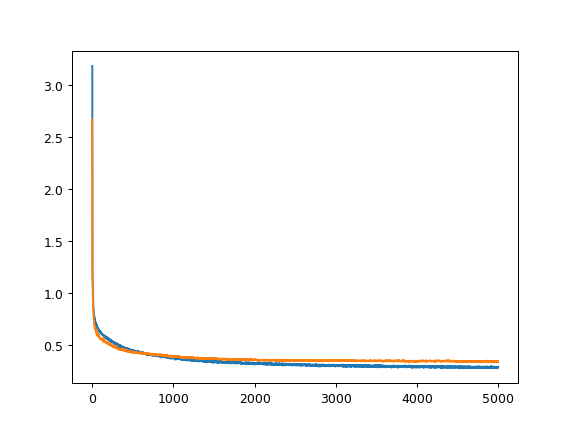

In [33]:
#Documents
#Logarithm
#No augmentation
#No keeping one sample together
# layers 8, 32, 64, 64, 32, 8
#batch size = 100
#Bigger network (64 neurons max)
#lr=0.001
#dropout =0.02

plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.01

## Prediction on test set

In [34]:
model.eval()
running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    else:
        res = torch.concat((res, abs(outputs-labels)), axis=0)
        lab = torch.concat((lab, labels), axis=0)
        out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [35]:
lab

tensor([[ 0.6814, -3.8429, -7.3168,  ..., -2.0901, -5.5168, -0.8327],
        [ 1.7116, -4.4546, -7.4808,  ..., -1.2107, -5.7975, -1.4870],
        [ 1.7433, -3.2536, -7.8672,  ..., -4.1254, -3.4859, -2.4003],
        ...,
        [ 1.5180, -2.1008, -6.8141,  ..., -3.6722, -4.1360,  0.2913],
        [-0.0894, -3.8682, -7.6653,  ..., -1.7766, -5.5490, -0.9989],
        [-0.3599, -5.9045, -7.8310,  ...,  1.1395, -2.5659, -0.6577]],
       device='cuda:0')

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [36]:
out

tensor([[ 0.2309, -3.6895, -7.7811,  ..., -2.0000, -5.5873, -0.5623],
        [ 1.8737, -4.2690, -7.8004,  ..., -1.3559, -5.4237, -1.5804],
        [ 1.5313, -3.3429, -7.8783,  ..., -4.2672, -3.3950, -2.5379],
        ...,
        [-0.8541, -4.1309, -8.6376,  ..., -4.6966, -3.5675,  0.1352],
        [-0.1107, -3.7354, -7.7759,  ..., -1.7911, -5.5031, -1.4629],
        [-0.2602, -5.5676, -8.2513,  ...,  1.0955, -2.9826, -0.6068]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [37]:
res

tensor([[0.4505, 0.1534, 0.4643,  ..., 0.0901, 0.0705, 0.2704],
        [0.1621, 0.1855, 0.3196,  ..., 0.1452, 0.3738, 0.0935],
        [0.2120, 0.0892, 0.0110,  ..., 0.1418, 0.0908, 0.1377],
        ...,
        [2.3721, 2.0301, 1.8235,  ..., 1.0244, 0.5685, 0.1561],
        [0.0213, 0.1328, 0.1106,  ..., 0.0145, 0.0459, 0.4641],
        [0.0997, 0.3369, 0.4204,  ..., 0.0440, 0.4167, 0.0509]],
       device='cuda:0', grad_fn=<CatBackward0>)

To calculate mean error on consecutive coordinates run:

In [38]:
torch.mean(res, axis=0) 

tensor([0.2783, 0.2999, 0.4530, 0.2176, 0.2875, 0.2955, 0.3441, 0.3266],
       device='cuda:0', grad_fn=<MeanBackward1>)

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Significance of elements: Cu >> Mn > Al > Zn > Pb > S > Cr > Co >> all the others.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [39]:
torch.mean(res)

tensor(0.3128, device='cuda:0', grad_fn=<MeanBackward0>)

In [37]:
torch.mean(res)

tensor(0.3756, device='cuda:0', grad_fn=<MeanBackward0>)

## Saving the model

In [40]:
import time
ts = time.time()
import datetime
now = datetime.datetime.fromtimestamp(ts).strftime('%Y_%m_%d_%H_%M_%S')

torch.save(model.state_dict(), models_path[object_name]+'model_regression_'+now)

### Visualisations

In [45]:
dim_nr = 2
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

<IPython.core.display.Javascript object>


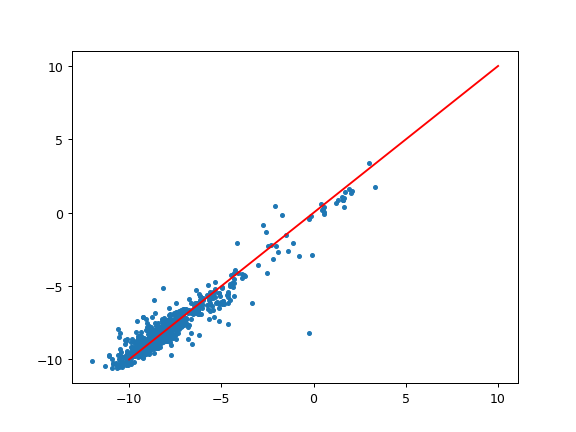

In [46]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [-10, 10],[-10, 10], 'red' )

## Quality of prediction: closest points

#### Creating df with means of classes

In [47]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds[object_name]]

In [48]:
train_val_df = pd.DataFrame(y_train.cpu())
train_val_df = pd.concat([train_val_df, 
                                    pd.DataFrame(y_val.cpu())])
train_val_df.columns = elements_names
train_val_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
train_val_df.reset_index(drop=True, inplace=True)

In [49]:
mean_df = train_val_df[['Sample_id']]

for name in elements_names:
    mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
    mean_df.drop_duplicates('Sample_id', inplace=True)
    
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_17931/649964028.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_17931/649964028.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_17931/649964028.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

#### Checking if there is any chance for it to work: if classes in y_test are close to means of classes in train_val set

In [50]:
y_test_df = pd.DataFrame(y_test.cpu())
y_test_df.columns = elements_names
y_test_df.insert(0, 'Sample_id', test_order)
y_test_df.reset_index(drop=True, inplace=True)

In [51]:
closest = []
for i in range(y_test_df.shape[0]):
    which_row = (abs(y_test_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [52]:
len(closest)

780

In [53]:
y_test_df['Closest'] = closest

In [54]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] 

724

In [55]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] / len(closest)

0.9282051282051282

#### Now let's check if it works for the neural network's output.

In [56]:
model.eval()
outputs = model(X_test)

In [57]:
outputs_df = pd.DataFrame(outputs.cpu().detach().numpy())
outputs_df.columns = elements_names
outputs_df.insert(0, 'Real sample_id', test_order)
outputs_df.reset_index(drop=True, inplace=True)

In [58]:
closest = []
for i in range(outputs_df.shape[0]):
    which_row = (abs(outputs_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [59]:
len(closest)

780

In [60]:
outputs_df['Closest'] = closest

In [61]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0]

587

In [62]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0] / len(closest)

0.7525641025641026

## Quality of prediction: confidence intervals

In [71]:
model.eval()
outputs = model(X_test)

In [72]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds[object_name]]

In [73]:
all_data_df = pd.DataFrame(y_train.cpu())
all_data_df = pd.concat([all_data_df, 
                        pd.DataFrame(y_val.cpu())])
all_data_df.columns = elements_names
all_data_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
all_data_df.reset_index(drop=True, inplace=True)

In [74]:
min_max_df = all_data_df[['Sample_id']]

for name in elements_names:
    min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    min_max_df[name + '_min'] = all_data_df.groupby('Sample_id')[name].transform('min')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
        
min_max_df.sort_values(by='Sample_id', inplace=True)
min_max_df.reset_index(drop=True, inplace=True)

max_df = min_max_df.iloc[:,1:(1+len(elements_names))]
max_df['Sample_id'] = min_max_df['Sample_id']
min_df = min_max_df.iloc[:,1+len(elements_names):]
min_df['Sample_id'] = min_max_df['Sample_id']

/tmp/ipykernel_7181/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
/tmp/ipykernel_7181/3264826654.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_7181/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

In [75]:
mean_sd_df = all_data_df[['Sample_id']]

for name in elements_names:
    mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    mean_sd_df[name + '_sd'] = all_data_df.groupby('Sample_id')[name].transform(np.std)
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_sd_df.sort_values(by='Sample_id', inplace=True)
mean_sd_df.reset_index(drop=True, inplace=True)

upper_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values + \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
upper_bound_df = pd.DataFrame(upper_bound_df, columns=elements_names)
upper_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

lower_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values - \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
lower_bound_df = pd.DataFrame(lower_bound_df, columns=elements_names)
lower_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

/tmp/ipykernel_7181/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_7181/2008320981.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_7181/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

In [76]:
min_max_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater_than_min = test_example.cpu().detach().numpy() > \
                    np.array(min_df.loc[min_df['Sample_id'] == sample_id, min_df.columns != 'Sample_id'])
    
    less_than_max = test_example.cpu().detach().numpy() < \
                    np.array(max_df.loc[max_df['Sample_id'] == sample_id, max_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater_than_min, less_than_max)
    
    #print(res)
    min_max_res_list.append(res)

In [77]:
sd_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater = test_example.cpu().detach().numpy() > \
    np.array(lower_bound_df.loc[lower_bound_df['Sample_id'] == sample_id, lower_bound_df.columns != 'Sample_id'])
    
    less = test_example.cpu().detach().numpy() < \
    np.array(upper_bound_df.loc[upper_bound_df['Sample_id'] == sample_id, upper_bound_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater, less)
    
    #print(res)
    sd_res_list.append(res)

In [78]:
elements_names

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb']

Percentage of points inside mean +- 2 standard deviations interval:

In [79]:
np.array(sd_res_list).mean()

0.5682692307692307

On consecutive coordinates:

In [80]:
np.array(sd_res_list).mean(0)

array([[0.67179487, 0.59871795, 0.75      , 0.46153846, 0.49487179,
        0.47692308, 0.53717949, 0.55512821]])

Percentage of points inside min-max interval:

In [81]:
np.array(min_max_res_list).mean()

0.4913461538461538

On consecutive coordinates:

In [82]:
np.array(min_max_res_list).mean(0)

array([[0.57564103, 0.53461538, 0.66410256, 0.38846154, 0.4025641 ,
        0.41538462, 0.47051282, 0.47948718]])

### Visualisations of mean +- 2 * standard deviation intervals

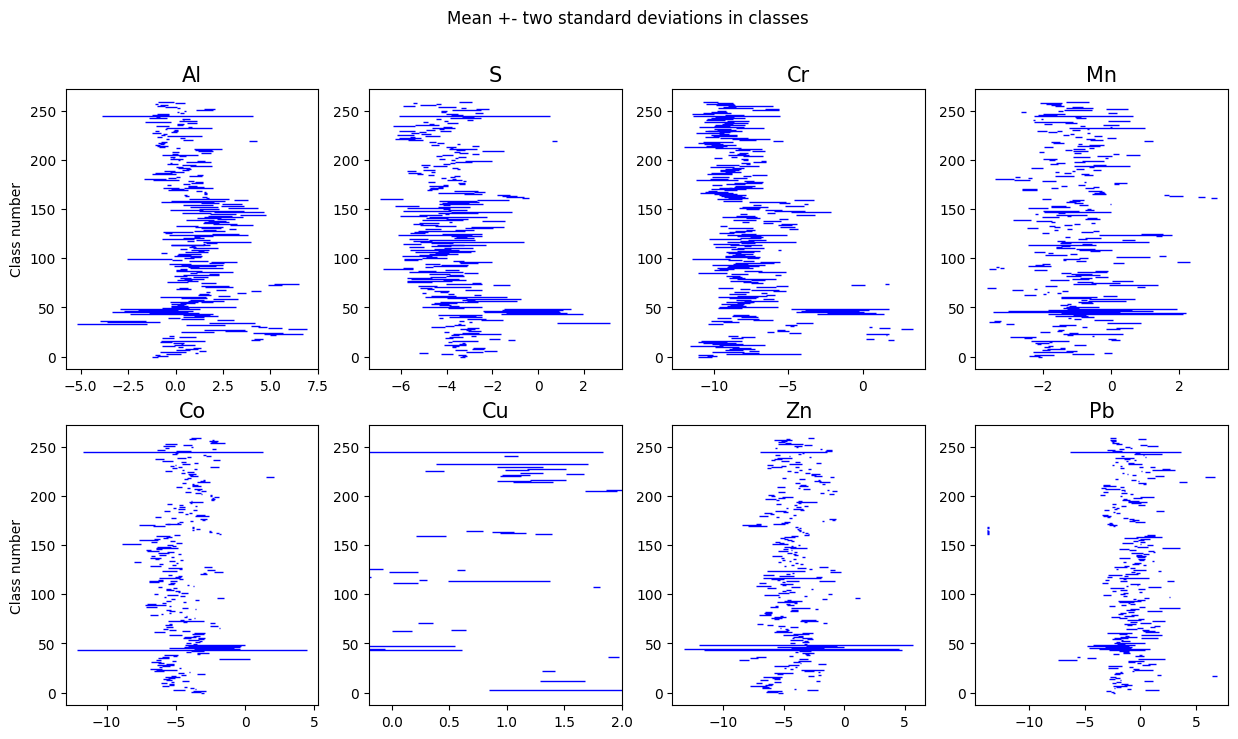

In [67]:
fig, ax = plt.subplots(2,4, figsize=(15,8))
plt.suptitle('Mean +- two standard deviations in classes')
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].hlines(y=sample_id, xmin=lower_bound_df.iloc[sample_id, element], 
                  xmax=upper_bound_df.iloc[sample_id, element], 
                  color="blue", linewidth=1)
        ax[element//4][element%4].set_title(elements_names[element], size=15)
        if element == 5:
            ax[element//4][element%4].set_xlim([-0.2, 2.0])
        if element == 0 or element == 4:
            ax[element//4][element%4].set_ylabel('Class number')
#plt.savefig(figures_path + 'intervals.png', dpi=300)

### Visualisations of min-max intervals

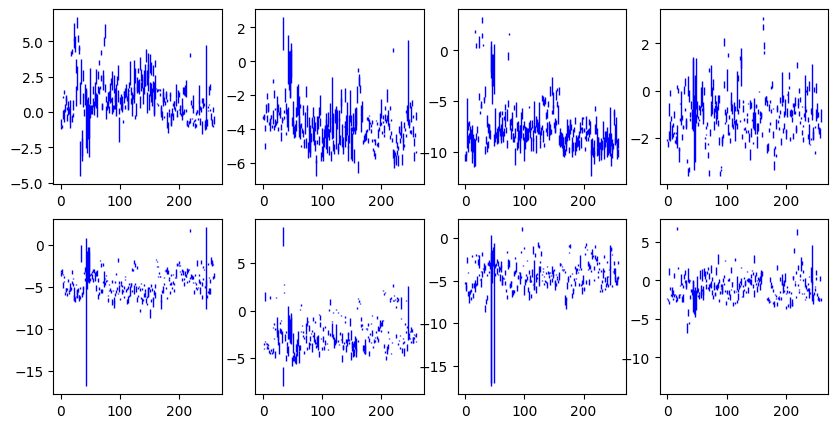

In [68]:
fig, ax = plt.subplots(2,4, figsize=(10,5))
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)
        #ax[element%4][element%2].set_title(elements_names[element])

For a single element:

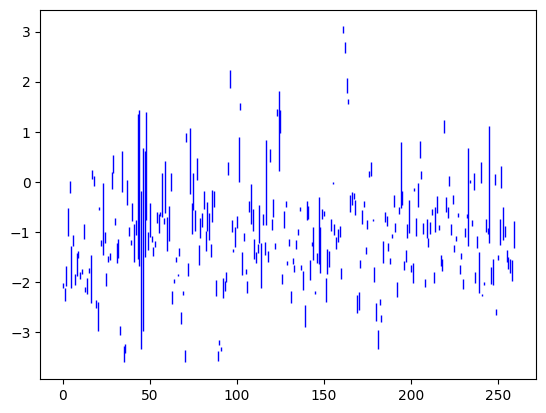

In [69]:
element = 3
for sample_id in range(min_max_df.shape[0]):
    plt.vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)

## Interpretability